In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import pandas as pd
from scipy import stats
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

Change working directory

In [2]:
notebook_path = %pwd

os.chdir(Path(notebook_path).parent)
os.getcwd()

'/home/atleeri/repositories/forecast-electricity-markets'

Load processed data

In [3]:
processed_data_dir = Path('data/processed')
filepaths = list(processed_data_dir.glob('**/*60*.parquet'))
filepaths

[PosixPath('data/processed/opsd-time_series-2020-10-06/time_series_60min_singleindex.parquet')]

In [17]:
filepath = filepaths[0]
df = pd.read_parquet(filepath)
df

,utc_timestamp,cet_cest_timestamp,DE_wind_generation,DE_price_ahead
0,2014-12-31 23:00:00+00:00,2015-01-01 00:00:00+01:00,NaN,NaN
1,2015-01-01 00:00:00+00:00,2015-01-01 01:00:00+01:00,8852.0,NaN
2,2015-01-01 01:00:00+00:00,2015-01-01 02:00:00+01:00,9054.0,NaN
3,2015-01-01 02:00:00+00:00,2015-01-01 03:00:00+01:00,9070.0,NaN
4,2015-01-01 03:00:00+00:00,2015-01-01 04:00:00+01:00,9163.0,NaN
...,...,...,...,...
50396,2020-09-30 19:00:00+00:00,2020-09-30 20:00:00+01:00,10654.0,49.92
50397,2020-09-30 20:00:00+00:00,2020-09-30 21:00:00+01:00,11836.0,42.79
50398,2020-09-30 21:00:00+00:00,2020-09-30 22:00:00+01:00,12168.0,35.02
50399,2020-09-30 22:00:00+00:00,2020-09-30 23:00:00+01:00,12533.0,34.40


Subsample (for now, just use all of the data)

In [70]:
df_sample = df[:]

In [75]:
df_sample

,utc_timestamp,cet_cest_timestamp,DE_wind_generation,DE_price_ahead
32856,2018-09-30 23:00:00+00:00,2018-10-01 00:00:00+01:00,6042.0,56.10
32857,2018-10-01 00:00:00+00:00,2018-10-01 01:00:00+01:00,6021.0,51.41
32858,2018-10-01 01:00:00+00:00,2018-10-01 02:00:00+01:00,6342.0,47.38
32859,2018-10-01 02:00:00+00:00,2018-10-01 03:00:00+01:00,7144.0,47.59
32860,2018-10-01 03:00:00+00:00,2018-10-01 04:00:00+01:00,7855.0,51.61
...,...,...,...,...
50395,2020-09-30 18:00:00+00:00,2020-09-30 19:00:00+01:00,8526.0,55.34
50396,2020-09-30 19:00:00+00:00,2020-09-30 20:00:00+01:00,10654.0,49.92
50397,2020-09-30 20:00:00+00:00,2020-09-30 21:00:00+01:00,11836.0,42.79
50398,2020-09-30 21:00:00+00:00,2020-09-30 22:00:00+01:00,12168.0,35.02


Remove NaNs

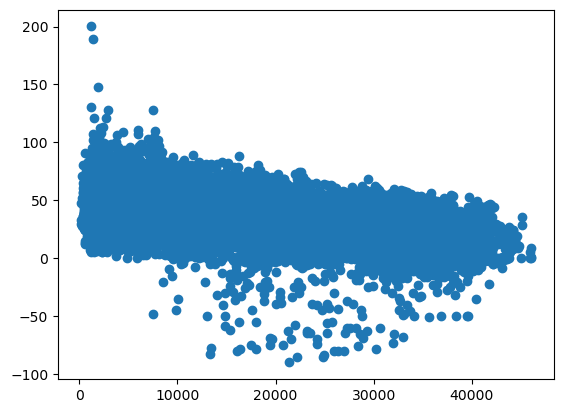

In [72]:
valid_mask = df_sample['DE_wind_generation'].notna() & df_sample['DE_price_ahead'].notna()
plt.scatter(df_sample[valid_mask]['DE_wind_generation'], df_sample[valid_mask]['DE_price_ahead'])

df_sample = df_sample[valid_mask]

### Linear Regression on All of the Data with Scipy.Stats and with PyTorch

In [91]:
X = df_sample['DE_wind_generation']
y = df_sample['DE_price_ahead']

Linear regression with scipy.stats

In [92]:
reg = stats.linregress(X, y)
reg

LinregressResult(slope=np.float64(-0.0006888959392140089), intercept=np.float64(45.709930798488095), rvalue=np.float64(-0.39179925143475863), pvalue=np.float64(0.0), stderr=np.float64(1.2215514524717343e-05), intercept_stderr=np.float64(0.21609572632577728))

Linear regression with PyTorch Linear model

In [93]:
# make tensors out of data

X_tensor = torch.tensor(df_sample['DE_wind_generation'].values, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(df_sample['DE_price_ahead'].values, dtype=torch.float32).unsqueeze(1)

In [94]:
# create model
model = nn.Linear(1,1)

In [95]:
# train

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.05)

nepochs = 12000

losses = []
for epoch in range(nepochs):
    optimizer.zero_grad()

    y_out = model(X_tensor)

    loss = criterion(y_out, y_tensor)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())


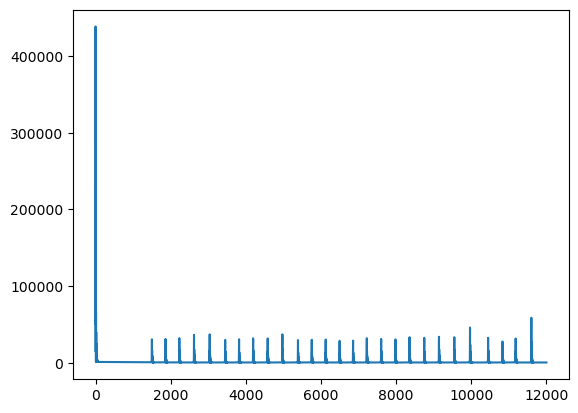

In [96]:
plt.plot(losses)

#### Plot Results

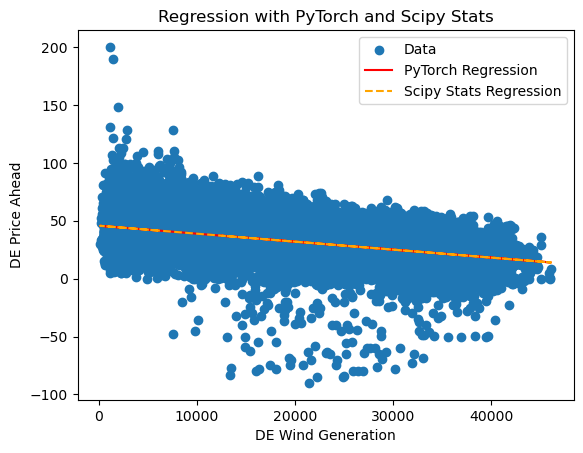

In [97]:
plt.scatter(X, y, label='Data')
with torch.no_grad():
    plt.plot(X, y_out.flatten(), 'r', label = 'PyTorch Regression')
plt.plot(X, reg[0]*X.values.flatten()+reg[1], 'orange', ls = '--', label = 'Scipy Stats Regression')
plt.title('Regression with PyTorch and Scipy Stats')
plt.xlabel('DE Wind Generation')
plt.ylabel('DE Price Ahead')
plt.legend()

Text(0, 0.5, 'Price Ahead')

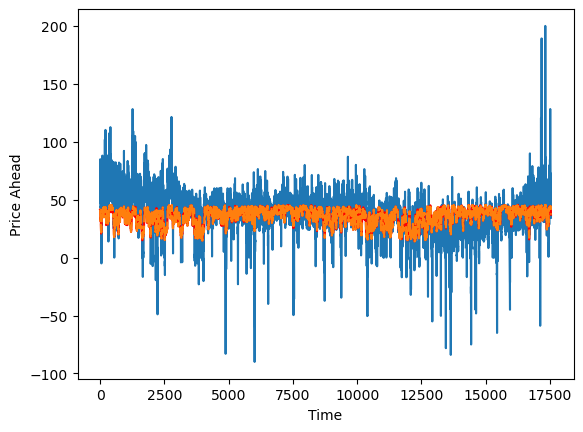

In [106]:
plt.plot(y_tensor, label = 'Data')
with torch.no_grad():
    plt.plot(y_out.flatten(), 'r', label = 'PyTorch')

plt.plot(reg[0]*X.values.flatten()+reg[1], '--', label = 'Scipy Stats')
plt.xlabel('Time')
plt.ylabel('Price Ahead')

## Use Regression to Create Baseline Forecast

#### Split Dataset into Train and Test Subsets

In [107]:
frac_train = 0.8
frac_test = 1 - frac_train

df_train = df_sample[:int(frac_train*len(df_sample))]
df_test = df_sample[int(frac_test*len(df_sample)):]


In [108]:
# make tensors out of data

X_train = torch.tensor(df_train['DE_wind_generation'].values, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(df_train['DE_price_ahead'].values, dtype=torch.float32).unsqueeze(1)

In [109]:
# create model
model = nn.Linear(1,1)

In [110]:
# train

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.05)

nepochs = 12000

losses = []
for epoch in range(nepochs):
    optimizer.zero_grad()

    y_out = model(X_train)

    loss = criterion(y_out, y_train)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())


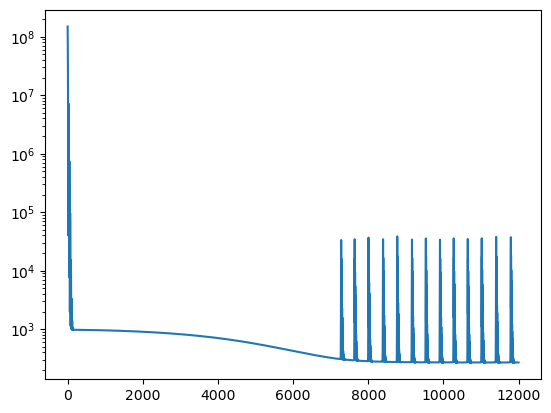

In [111]:
plt.semilogy(losses)

In [112]:
slope = model.weight[0].item()
bias = model.bias[0].item()

#### Test Model

In [113]:
# make tensors out of data

X_test = torch.tensor(df_test['DE_wind_generation'].values, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(df_test['DE_price_ahead'].values, dtype=torch.float32).unsqueeze(1)

Make Prediction

In [ ]:
y_pred = model(X_test)

Plot Results

Text(0, 0.5, 'Price Ahead')

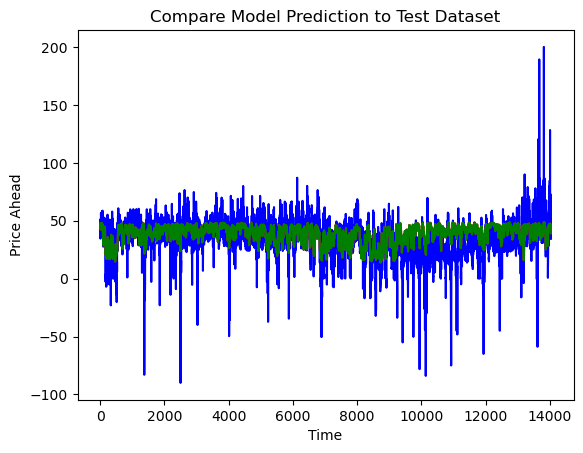

In [120]:
plt.plot(y_test, 'b', label = 'Data')
with torch.no_grad():
    plt.plot(y_pred, 'r', label = 'Model Prediction')

plt.title('Compare Model Prediction to Test Dataset')
plt.xlabel('Time')
plt.ylabel('Price Ahead')

In [124]:
mse_test = nn.MSELoss()(y_pred, y_test)
mse_test

tensor(243.0990)